![alt text](21-1.jpg)

In [1]:
import numpy as np

# np.random.randn(行, 列) 生成标准正态分布随机数
X = np.random.randn(3, 4)
print("矩阵 X (3×4):")
print(X)
print("-"*50)

Y = np.ones((4, 2))
print("矩阵 Y (4×2):")
print(Y)
print("-"*50)

Z = np.dot(X, Y)
print("矩阵 Z (3×2):")
print(Z)
print("-"*50)

elem = Z[0, 1]
# 第2行所有元素：行索引1
row_2 = Z[1, :]

print(f"Z 第一行第二列的元素：{elem}")
print(f"Z 第2行所有元素：{row_2}")
print("-"*50)

fro_norm = np.linalg.norm(Z)
print(f"Z 的 Frobenius 范数：{fro_norm}")

矩阵 X (3×4):
[[-0.88628086 -0.85517578  0.34109924 -0.87598773]
 [ 1.11730633 -0.05921935  0.23128645  1.15617256]
 [ 0.19963057  0.86296689  0.24820075 -0.18112402]]
--------------------------------------------------
矩阵 Y (4×2):
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
--------------------------------------------------
矩阵 Z (3×2):
[[-2.27634513 -2.27634513]
 [ 2.44554598  2.44554598]
 [ 1.12967418  1.12967418]]
--------------------------------------------------
Z 第一行第二列的元素：-2.2763451316970316
Z 第2行所有元素：[2.44554598 2.44554598]
--------------------------------------------------
Z 的 Frobenius 范数：4.987706101285084


![alt text](31-1.jpg)

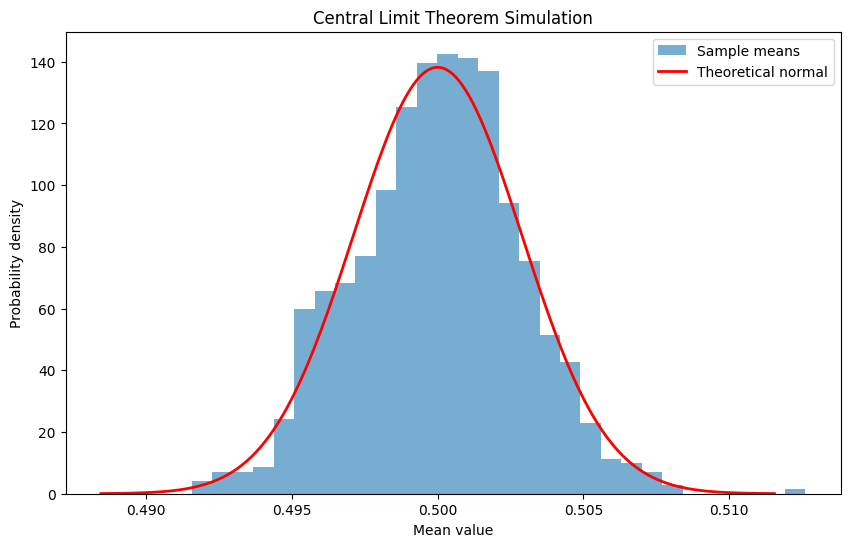

Actual variance: 8.117846436387085e-06
Theoretical variance: 8.333333333333334e-06


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n = 10000
m = 1000

# Generate sample means
samples = np.random.uniform(0, 1, (m, n))
means = samples.mean(axis=1)

# Theoretical normal distribution
mu = 0.5
sigma = np.sqrt(1 / (12 * n))
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
y = np.exp(-(x - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))

# Plot
plt.figure(figsize=(10, 6))
plt.hist(means, bins=30, density=True, alpha=0.6, label='Sample means')
plt.plot(x, y, 'r-', lw=2, label='Theoretical normal')
plt.xlabel('Mean value')
plt.ylabel('Probability density')
plt.title('Central Limit Theorem Simulation')
plt.legend()
plt.show()

# Output variances
print("Actual variance:", np.var(means))
print("Theoretical variance:", 1/(12*n))

![alt text](41-1.jpg)

In [5]:
import torch

# 1. 给定数值
x = 2.0
w1 = 1.5
w2 = 0.5

# 2. 构造张量（需要求导的参数开启 requires_grad）
x_t = torch.tensor(x)
w1_t = torch.tensor(w1, requires_grad=True)
w2_t = torch.tensor(w2, requires_grad=True)

# 3. 前向传播（和手动完全一样）
a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t

# 4. 自动反向传播
L_t.backward()

# 5. 输出梯度
print("===== PyTorch 自动求导结果 =====")
print("dL/dw1 =", w1_t.grad.item())
print("dL/dw2 =", w2_t.grad.item())

===== PyTorch 自动求导结果 =====
dL/dw1 = 2.0
dL/dw2 = 1.0


![alt text](51-1.jpg)

In [7]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# ======================
# 1. 加载数据
# ======================
digits = load_digits()
X = digits.data  # (1797, 64) 已经展平
y = digits.target.reshape(-1, 1)

# 划分训练集、测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ======================
# 2. One-hot 编码
# ======================
enc = OneHotEncoder(sparse_output=False)
y_train_onehot = enc.fit_transform(y_train)
y_test_onehot = enc.transform(y_test)

# ======================
# 3. 手动实现 softmax & 交叉熵
# ======================
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # 防溢出
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    n = y_true.shape[0]
    loss = -np.sum(y_true * np.log(y_pred + 1e-8)) / n
    return loss

# ======================
# 4. 初始化参数
# ======================
input_dim = 64
output_dim = 10
W = np.random.randn(input_dim, output_dim) * 0.01
b = np.zeros((1, output_dim))

# ======================
# 5. 超参数
# ======================
batch_size = 32
lr = 0.1
epochs = 50

# ======================
# 6. 小批量梯度下降训练
# ======================
n_train = X_train.shape[0]

for epoch in range(epochs):
    # 打乱数据
    indices = np.arange(n_train)
    np.random.shuffle(indices)
    X_shuffled = X_train[indices]
    y_shuffled = y_train_onehot[indices]

    total_loss = 0
    for i in range(0, n_train, batch_size):
        # 取小批量
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        n_batch = X_batch.shape[0]

        # 前向传播
        z = X_batch @ W + b
        y_pred = softmax(z)

        # 损失
        loss = cross_entropy_loss(y_pred, y_batch)
        total_loss += loss * n_batch

        # 反向传播（梯度）
        dz = (y_pred - y_batch) / n_batch
        dW = X_batch.T @ dz
        db = np.sum(dz, axis=0, keepdims=True)

        # 更新参数
        W -= lr * dW
        b -= lr * db

    # 每个 epoch 打印损失
    avg_loss = total_loss / n_train
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

# ======================
# 7. 测试集准确率
# ======================
z_test = X_test @ W + b
y_pred_test = softmax(z_test)
pred_labels = np.argmax(y_pred_test, axis=1)
true_labels = np.argmax(y_test_onehot, axis=1)

accuracy = np.mean(pred_labels == true_labels)
print("\nTest Accuracy: {:.2f}%".format(accuracy * 100))

Epoch 10/50, Loss: 0.2023
Epoch 20/50, Loss: 0.1656
Epoch 30/50, Loss: 0.0322
Epoch 40/50, Loss: 0.0145
Epoch 50/50, Loss: 0.0002

Test Accuracy: 96.67%


![alt text](611-1.jpg)

![alt text](612-1.jpg)

Epoch    0 | Loss: 0.6931
Epoch  100 | Loss: 0.0302
Epoch  200 | Loss: 0.0198
Epoch  300 | Loss: 0.0158
Epoch  400 | Loss: 0.0135
Epoch  500 | Loss: 0.0121
Epoch  600 | Loss: 0.0110
Epoch  700 | Loss: 0.0102
Epoch  800 | Loss: 0.0096
Epoch  900 | Loss: 0.0090

训练完成！
学习到的权重 w: [1.9081626  2.01069132]
学习到的偏置 b: 0.2149

测试集分类准确率: 100.00%


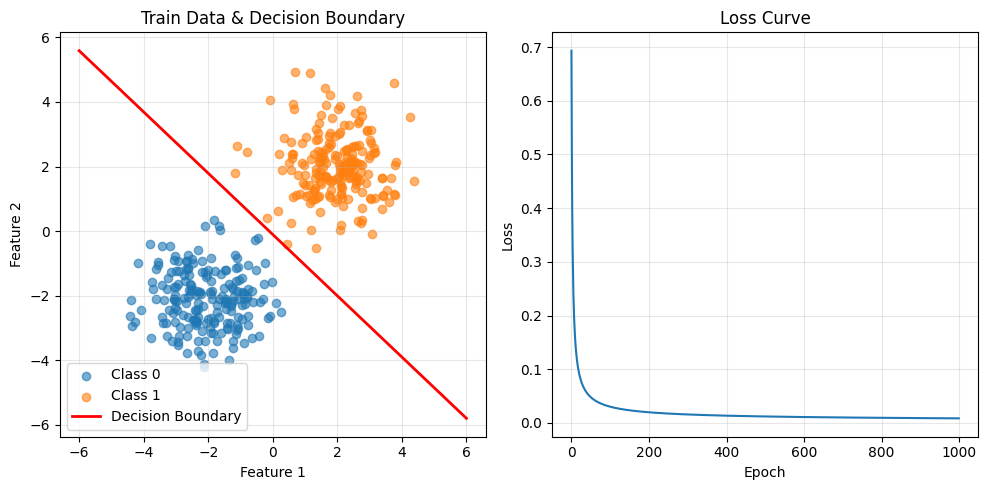

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# ===================== 1. 生成线性可分的二分类数据 =====================
np.random.seed(2025)  # 固定随机种子，结果可复现

# 类别 0：200个样本，2维特征
X0 = np.random.randn(200, 2) + np.array([-2, -2])
y0 = np.zeros(200)

# 类别 1：200个样本，2维特征
X1 = np.random.randn(200, 2) + np.array([2, 2])
y1 = np.ones(200)

# 拼接训练集
X_train = np.vstack((X0, X1))  # (400, 2)
y_train = np.hstack((y0, y1))  # (400,)

# 生成测试集：每类50个，共100个
X0_test = np.random.randn(50, 2) + np.array([-2, -2])
X1_test = np.random.randn(50, 2) + np.array([2, 2])
X_test = np.vstack((X0_test, X1_test))
y_test = np.hstack((np.zeros(50), np.ones(50)))

# ===================== 2. 定义sigmoid和交叉熵损失 =====================
def sigmoid(z):
    # 防止溢出，限制z范围
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_true, y_pred):
    # 避免log(0)
    epsilon = 1e-10
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

# ===================== 3. 梯度下降训练逻辑回归 =====================
# 初始化参数 w(2维), b(标量)
w = np.zeros(2)
b = 0.0

# 超参数
lr = 0.1        # 学习率
epochs = 1000   # 迭代次数
n = len(X_train)

loss_history = []

for i in range(epochs):
    # 前向传播
    z = np.dot(X_train, w) + b
    y_pred = sigmoid(z)
    
    # 计算损失
    loss = binary_cross_entropy(y_train, y_pred)
    loss_history.append(loss)
    
    # 计算梯度
    dw = (1 / n) * np.dot(X_train.T, (y_pred - y_train))
    db = (1 / n) * np.sum(y_pred - y_train)
    
    # 更新参数
    w -= lr * dw
    b -= lr * db
    
    # 每100轮打印损失
    if i % 100 == 0:
        print(f"Epoch {i:4d} | Loss: {loss:.4f}")

print("\n训练完成！")
print(f"学习到的权重 w: {w}")
print(f"学习到的偏置 b: {b:.4f}")

# ===================== 4. 测试集预测 & 计算准确率 =====================
def predict(X, w, b):
    z = np.dot(X, w) + b
    prob = sigmoid(z)
    return (prob >= 0.5).astype(int)  # 大于等于0.5判为类别1

y_pred_test = predict(X_test, w, b)
acc = accuracy_score(y_test, y_pred_test)
print(f"\n测试集分类准确率: {acc * 100:.2f}%")

# ===================== 绘制决策边界 =====================
plt.figure(figsize=(10, 5))

# 左图：训练数据+决策边界
plt.subplot(1, 2, 1)
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], label="Class 0", alpha=0.6)
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], label="Class 1", alpha=0.6)

# 绘制决策边界：w1*x1 + w2*x2 + b = 0 → x2 = (-w1*x1 - b)/w2
x1 = np.linspace(-6, 6, 100)
x2 = (-w[0] * x1 - b) / w[1]
plt.plot(x1, x2, 'r-', linewidth=2, label="Decision Boundary")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Train Data & Decision Boundary")
plt.legend()
plt.grid(alpha=0.3)

# 右图：损失下降曲线
plt.subplot(1, 2, 2)
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()